In [ ]:
import pandas as pd

df = pd.read_csv("paddydataset.csv")

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044
5,6,Chinnasalem,delux ponni,alluvial,150,75.0,wet,120,6,240,...,E,ENE,NE,NNW,78.6,80,92,88,480,36732
6,6,Cuddalore,CO_43,clay,150,75.0,wet,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,33162
7,6,Kurinjipadi,delux ponni,alluvial,150,75.0,dry,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,480,36690
8,6,Panruti,ponmani,clay,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,35310
9,6,Kallakurichi,CO_43,alluvial,150,75.0,dry,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,32460


CO_43         posterior mean = 22540 kg, 95% CI = (21876, 23205)
ponmani       posterior mean = 22411 kg, 95% CI = (21867, 22956)
delux ponni   posterior mean = 22614 kg, 95% CI = (22035, 23194)


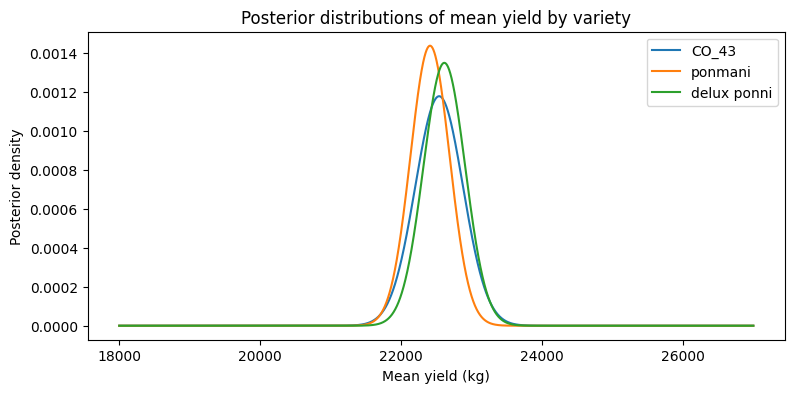

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#yields for each variety
varieties = ['CO_43', 'ponmani', 'delux ponni']
yields = {v: df.loc[df['Variety'] == v, 'Paddy yield(in Kg)'].values for v in varieties}

#priors
prior_mean, prior_sd = 22500, 5000

#grid over plausible mean yields
grid = np.linspace(18000, 27000, 5000)
dx = grid[1] - grid[0]

#compute posterior for each variety's mean
posteriors = {}
summaries = {}

for v in varieties:
    y = yields[v]
    n, m, s = len(y), y.mean(), y.std(ddof=1)
    se = s / np.sqrt(n)

    prior = np.exp(-0.5 * ((grid - prior_mean) / prior_sd) ** 2)
    likelihood = np.exp(-0.5 * ((m - grid) / se) ** 2)
    post = prior * likelihood
    post /= np.trapezoid(post, grid)
    posteriors[v] = post

    post_mean = np.trapezoid(grid * post, grid)
    cdf = np.cumsum(post) * dx
    ci_low  = grid[np.searchsorted(cdf, 0.025)]
    ci_high = grid[np.searchsorted(cdf, 0.975)]
    summaries[v] = (post_mean, ci_low, ci_high)

    print(f"{v:12s}  posterior mean = {post_mean:.0f} kg, "
          f"95% CI = ({ci_low:.0f}, {ci_high:.0f})")

#plot the three posteriors on the same axes
plt.figure(figsize=(9, 4))
for v in varieties:
    plt.plot(grid, posteriors[v], label=v)
plt.xlabel('Mean yield (kg)')
plt.ylabel('Posterior density')
plt.title('Posterior distributions of mean yield by variety')
plt.legend()
plt.show()